# Phase 2: Baseline CNN

In this phase, we will build, train, and evaluate a CNN model from scratch.

In [90]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

**Project Paths**

In [91]:
project_path = "/home/arslan/projects/skin-lesion-classifier"
processed_path = project_path + "/data/processed"

print("Processed data folder:", processed_path)

Processed data folder: /home/arslan/projects/skin-lesion-classifier/data/processed


**Load the Saved Dataset Splits**

In [92]:
train_df = pd.read_csv(processed_path + "/train.csv")
val_df = pd.read_csv(processed_path + "/validation.csv")
test_df = pd.read_csv(processed_path + "/test.csv")

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 7014
Validation images: 1509
Testing images: 1492


**Verify Dataset Split**

In [95]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train-Val overlap:", len(train_lesions & val_lesions))
print("Train-Test overlap:", len(train_lesions & test_lesions))
print("Val-Test overlap:", len(val_lesions & test_lesions))

total_images = len(train_df) + len(val_df) + len(test_df)
print("Total images:", total_images)

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
Total images: 10015


**Calculate Class Weights**

In [93]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weight_dict = dict(enumerate(class_weights.tolist()))

print(class_weight_dict)

{0: 4.263829787234043, 1: 2.745205479452055, 2: 1.3324468085106382, 3: 12.683544303797468, 4: 1.2651515151515151, 5: 0.21364605543710022, 6: 9.92079207920792}


**Set image size and batch size**

In [96]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


**Preprocessing**

In [97]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)


In [98]:
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

In [99]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

Found 7014 validated image filenames.


In [100]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1509 validated image filenames.


In [101]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 1492 validated image filenames.


**Build the baseline CNN model**

In [103]:
baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(7, activation="softmax")
])

In [104]:
baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,071 (500.28 KB)

 Trainable params: 128,071 (500.28 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
#Compile the model

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


**Create training callbacks**

In [108]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        project_path + "/models/baseline/best_baseline.keras",
        save_best_only=True
    )
]

This stops training if validation loss does not improve for 3 epochs and restores the best model weights.

**Train Model**

In [109]:
history = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15


I0000 00:00:1781907389.510016  403207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50439__.42


113/220 ━━━━━━━━━━━━━━━━━━━━ 42s 401ms/step - accuracy: 0.1604 - loss: 1.9529

I0000 00:00:1781907437.807768  403205 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50439__.42
I0000 00:00:1781907442.545261  449459 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads



220/220 ━━━━━━━━━━━━━━━━━━━━ 114s 493ms/step - accuracy: 0.3179 - loss: 1.9208 - val_accuracy: 0.4672 - val_loss: 1.4433
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 85s 386ms/step - accuracy: 0.3504 - loss: 1.7968 - val_accuracy: 0.2671 - val_loss: 1.5920
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 83s 378ms/step - accuracy: 0.3201 - loss: 1.7893 - val_accuracy: 0.3433 - val_loss: 1.5171
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 86s 388ms/step - accuracy: 0.3502 - loss: 1.7749 - val_accuracy: 0.1007 - val_loss: 2.2627


In [125]:
best_epoch = np.argmin(history.history["val_loss"])

print("Epochs completed:", len(history.history["loss"]))
print("Best epoch:", best_epoch + 1)
print("Training accuracy:", history.history["accuracy"][best_epoch])
print("Validation accuracy:", history.history["val_accuracy"][best_epoch])
print("Training loss:", history.history["loss"][best_epoch])
print("Validation loss:", history.history["val_loss"][best_epoch])

Epochs completed: 4
Best epoch: 1
Training accuracy: 0.3179355561733246
Validation accuracy: 0.46719682216644287
Training loss: 1.9207792282104492
Validation loss: 1.4432759284973145


**Evaluate the trained model**

In [111]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 319ms/step - accuracy: 0.4578 - loss: 1.4564
Test accuracy: 0.4577747881412506
Test loss: 1.4563891887664795


**Generate Test Predictions**

In [112]:
test_generator.reset()

predictions = baseline_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step


**Get the true test labels**

In [113]:
true_labels = test_df["label"].to_numpy()

print("True labels:", len(true_labels))
print("Predicted labels:", len(predicted_labels))

True labels: 1492
Predicted labels: 1492


**Classification Report**

In [115]:
from sklearn.metrics import classification_report

class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       akiec       0.05      0.02      0.03        42
         bcc       0.00      0.00      0.00        76
         bkl       0.00      0.00      0.00       167
          df       0.04      0.79      0.08        19
         mel       0.17      0.28      0.21       159
          nv       0.82      0.62      0.70      1006
        vasc       0.00      0.00      0.00        23

    accuracy                           0.46      1492
   macro avg       0.15      0.24      0.15      1492
weighted avg       0.57      0.46      0.50      1492



**Confusion Matrix**

In [116]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    true_labels,
    predicted_labels
)

print(confusion)

[[  1   0   0  23   7   9   2]
 [  2   0   0  58   9   3   4]
 [  4   0   0  96  22  37   8]
 [  1   0   0  15   1   2   0]
 [  2   0   0  16  45  87   9]
 [ 11   0   0 153 178 622  42]
 [  0   0   0  16   5   2   0]]


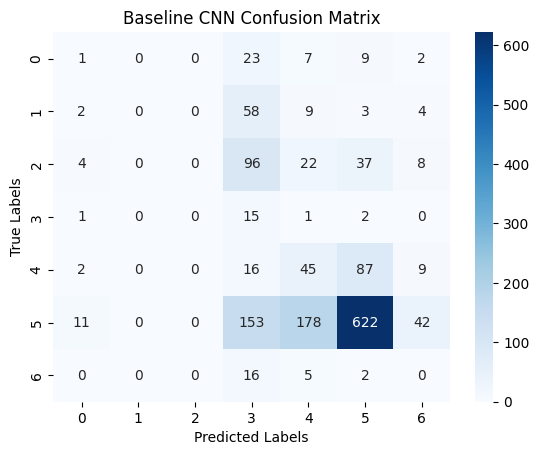

In [117]:
import seaborn as sns

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Baseline CNN Confusion Matrix")
plt.show()

**Final Evaluation Metrics**

In [120]:
from sklearn.metrics import recall_score, precision_score, f1_score

weighted_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro"
)

melanoma_recall = recall_score(
    true_labels,
    predicted_labels,
    labels=[4],
    average=None,
    zero_division=0
)[0]

melanoma_precision = precision_score(
    true_labels,
    predicted_labels,
    labels=[4],
    average=None,
    zero_division=0
)[0]

print("Weighted F1-score:", weighted_f1)
print("Macro F1-score:", macro_f1)
print("Melanoma recall:", melanoma_recall)
print("Melanoma precision:", melanoma_precision)

Weighted F1-score: 0.4987975238121836
Macro F1-score: 0.14605587466281042
Melanoma recall: 0.2830188679245283
Melanoma precision: 0.16853932584269662


**Save Trained Baseline Model**

In [121]:
baseline_model.save(
    project_path + "/models/baseline/baseline_cnn.keras"
)

print("Baseline model saved successfully.")

Baseline model saved successfully.


**Plot Training & Validation Accuracy**

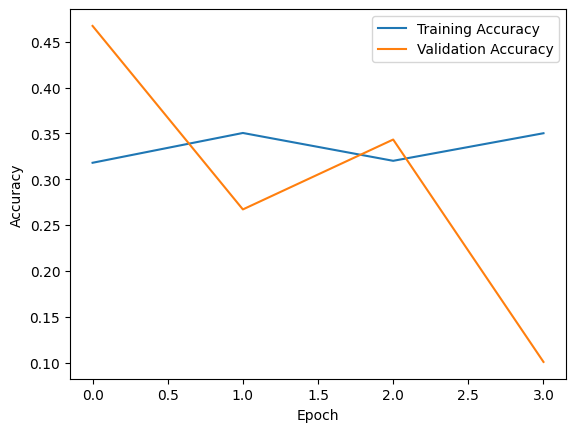

In [122]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Plot Training & Validation Loss**

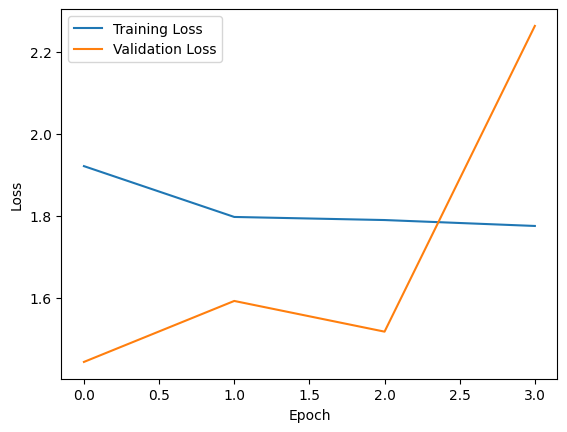

In [123]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Phase 2: Baseline CNN Completed ✅

The baseline CNN was built, trained, and evaluated on the HAM10000 dataset.

## Final Results

* Best epoch: 1
* Validation accuracy: 46.72%
* Test accuracy: 45.78%
* Test loss: 1.456
* Weighted F1-score: 0.499
* Macro F1-score: 0.146
* Melanoma recall: 28.30%
* Melanoma precision: 16.85%

The model performed best on the majority `nv` class but performed poorly on melanoma and some rare classes.

This baseline model will be compared with MobileNetV2 in Phase 3.
